In [39]:
# load dataset 
# Step 1 - load dataset

import pandas as pd
from sklearn.datasets import load_wine # load the wine dataset

wine = load_wine() # load the wine dataset
X = wine.data # features (column)
y = wine.target # target variable (column)

df = pd.DataFrame(data=wine.data, columns=wine.feature_names) # create a DataFrame with the features
# df.head() # display the first 5 rows of the DataFrame

df['class'] = wine.target # add the target variable to the DataFrame
df.head() # display the first 5 rows of the DataFrame with the target variable


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [40]:
# check shape of the dataset
print("Shape of the dataset:", df.shape) 

Shape of the dataset: (178, 14)


In [41]:
# check information about the dataset
print("\nInformation about the dataset:")
print(df.info())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       17

In [42]:
# apply LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

lda = LinearDiscriminantAnalysis(n_components=2) # create an LDA object with 2 components
X_lda = lda.fit_transform(X, y) # fit and transform the data using LDA

In [43]:
# convert the LDA result into a DataFrame for better visualization
lda_df = pd.DataFrame(data=X_lda,columns=['LD1','LD2'])
lda_df['class'] = wine.target_names[wine.target]

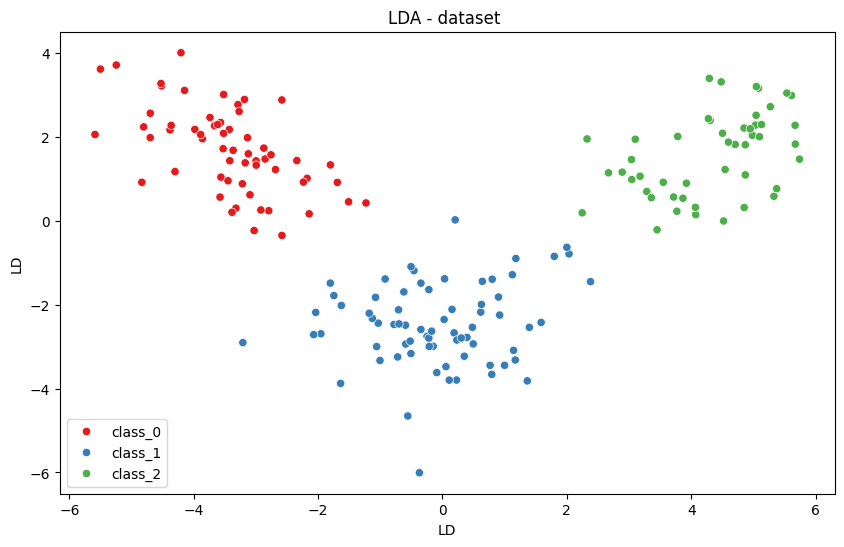

In [44]:
# result visualize 
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='LD1',y='LD2',hue='class',data=lda_df,palette='Set1')
plt.title("LDA - dataset ")
plt.xlabel('LD')
plt.ylabel('LD')
plt.legend(loc='best')
plt.show()

In [45]:
# Evaluate the model 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# split the data 
# 30% test data
# 70% traning data

X_train ,X_test ,y_train , y_test = train_test_split(X , y, test_size=0.3,random_state=42)
# train the LDA model 
lda.fit(X_train,y_train)

# data 
print(df.shape)
print(X_train.shape)
print(X_test.shape)


(178, 14)
(124, 13)
(54, 13)


In [46]:
# predict the classes for the test set 30%
y_pred = lda.predict(X_test)

In [47]:
# evaluate the model 
print('accuracry score = ',accuracy_score(y_test,y_pred))
print('classification report = ',classification_report(y_test,y_pred,target_names=wine.target_names))

accuracry score =  1.0
classification report =                precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

